[ 0.84255206  0.89220511  0.93290779  0.96425181  0.98592271  0.99770312
  0.99947484  0.99122011  0.97302173  0.94506227  0.9076222   0.86107713
  0.80589396  0.74262629  0.6719088   0.5944509   0.51102964  0.42248187
  0.32969589  0.23360248  0.13516563  0.03537285 -0.06477479 -0.16427262
 -0.26212252 -0.35734288 -0.44897847 -0.53611004 -0.61786349 -0.69341871
 -0.76201775 -0.82297244 -0.8756713  -0.91958566 -0.95427499 -0.97939131
 -0.99468264 -0.99999559 -0.99527686 -0.98057379 -0.95603388 -0.9219033
 -0.87852444 -0.82633246 -0.76585095 -0.69768664 -0.62252332 -0.54111503
 -0.45427842 -0.36288461 -0.26785044 -0.17012928 -0.07070142  0.02943569
  0.12927751  0.22782246  0.32408195  0.41709035  0.50591461  0.58966367
  0.66749739  0.73863497  0.80236276  0.85804147  0.90511255  0.94310378
  0.97163407  0.99041719  0.99926471  0.9980879   0.98689854  0.96580889
  0.93503051  0.89487216  0.84573671  0.78811706  0.72259123  0.64981657
  0.57052314  0.48550637  0.39561914  0.30176316  0.

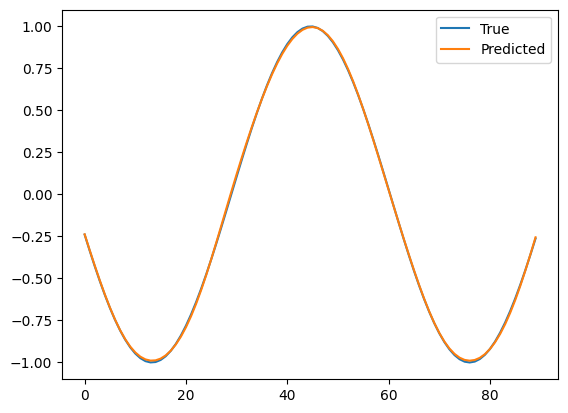

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 创建正弦波数据
def generate_data(seq_length, num_samples):
    x = np.linspace(0, 50, num_samples)
    y = np.sin(x)
    
    inputs = []  # 存储输入序列
    targets = []  # 存储输出值
    
    for i in range(len(y) - seq_length):
        inputs.append(y[i:i+seq_length])  # 输入序列
        targets.append(y[i+seq_length])  # 输出值
    
    # 转换为 NumPy 数组
    inputs = np.array(inputs)  # 形状为 (490, seq_length)
    targets = np.array(targets)  # 形状为 (490,)
    
    return inputs, targets

# 数据参数
seq_length = 10
num_samples = 500

# 生成数据
inputs, targets = generate_data(seq_length, num_samples)

# 数据拆分
train_inputs = inputs[:400]
train_targets = targets[:400]
test_inputs = inputs[400:]
test_targets = targets[400:]

# 转换为 PyTorch 张量
train_x = torch.tensor(train_inputs, dtype=torch.float32)
train_y = torch.tensor(train_targets, dtype=torch.float32)
test_x = torch.tensor(test_inputs, dtype=torch.float32)
test_y = torch.tensor(test_targets, dtype=torch.float32)


# 2. 定义 LSTM 模型
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # 初始化隐藏状态和记忆单元状态
        h0 = torch.zeros(num_layers, x.size(0), hidden_size)
        c0 = torch.zeros(num_layers, x.size(0), hidden_size)
        
        # LSTM 输出
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # 取最后一个时间步的输出
        return out

# 3. 模型参数
input_size = 1
hidden_size = 32
num_layers = 1
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size)

# 4. 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 5. 训练模型
num_epochs = 100
train_x = train_x.unsqueeze(-1)  # 添加特征维度
test_x = test_x.unsqueeze(-1)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_x)
    loss = criterion(outputs.squeeze(), train_y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# 6. 测试模型
model.eval()
predicted = model(test_x).detach().numpy()

# 7. 可视化结果
plt.plot(range(len(test_y)), test_y, label='True')
plt.plot(range(len(predicted)), predicted, label='Predicted')
plt.legend()
plt.show()

In [ ]:
# 模型定义
class LSTMRegression(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMRegression, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(num_layers, x.size(0), hidden_size)
        c0 = torch.zeros(num_layers, x.size(0), hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# 初始化模型
input_size = 1
hidden_size = 32
num_layers = 1
output_size = 1

model = LSTMRegression(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 训练模型
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_x)
    loss = criterion(outputs.squeeze(), train_y)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# 测试模型
model.eval()
with torch.no_grad():
    predicted = model(test_x).squeeze().numpy()
    predicted = scaler.inverse_transform(predicted.reshape(-1, 1)).flatten()
    true_values = scaler.inverse_transform(test_y.numpy().reshape(-1, 1)).flatten()

In [ ]:

class StackedLSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob):
        super(StackedLSTMWithAttention, self).__init__()
        
        # 堆叠多层 LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_prob)
        
        # Attention 层
        self.attention = nn.Linear(hidden_size, 1)
        
        # 全连接层
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # 初始化隐藏状态和记忆单元
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size)
        
        # LSTM 输出
        lstm_out, _ = self.lstm(x, (h0, c0))  # lstm_out: [batch_size, seq_length, hidden_size]
        
        # Attention 机制
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # [batch_size, seq_length, 1]
        context = torch.sum(attn_weights * lstm_out, dim=1)  # 加权求和, [batch_size, hidden_size]
        
        # 全连接层输出
        out = self.fc(context)  # [batch_size, output_size]
        return out
    
    # 模型参数
input_size = 1
hidden_size = 64
num_layers = 3  # 堆叠 3 层
output_size = 1
dropout_prob = 0.3

# 初始化模型
model = StackedLSTMWithAttention(input_size, hidden_size, num_layers, output_size, dropout_prob)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_x)
    loss = criterion(outputs.squeeze(), train_y)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')